In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from PIL import Image, ImageChops
import os


left_dir = '/content/drive/MyDrive/Colab Notebooks/Binary Segmentation/Montgomery/MontgomerySet/ManualMask/leftMask'
right_dir = '/content/drive/MyDrive/Colab Notebooks/Binary Segmentation/Montgomery/MontgomerySet/ManualMask/rightMask'
final_dir = '/content/drive/MyDrive/Colab Notebooks/Binary Segmentation/Montgomery/MontgomerySet/ManualMask/FinalMasks'

for num, filename in enumerate(os.listdir(left_dir)):
  im_left = Image.open(os.path.join(left_dir, filename))
  im_right = Image.open(os.path.join(right_dir, filename))
  im_final = ImageChops.add(im_left, im_right).resize((572, 572))
  im_final.save(os.path.join(final_dir, str(num) + '.png'))

In [ ]:
monrgomery_dir = '/content/drive/MyDrive/Colab Notebooks/Binary Segmentation/Montgomery/MontgomerySet/CXR_png'

for num, filename in enumerate(os.listdir(monrgomery_dir)):
  im = Image.open(os.path.join(monrgomery_dir, filename))
  im = im.resize((572, 572))
  im.save(os.path.join(monrgomery_dir, str(num) + '.png'))

In [ ]:
shenzhen_im_dir = '/content/drive/MyDrive/Colab Notebooks/Binary Segmentation/Shenzhen/Images'
shenzhen_mask_dir = '/content/drive/MyDrive/Colab Notebooks/Binary Segmentation/Shenzhen/Masks'

for num, filename in enumerate(os.listdir(shenzhen_im_dir)):
  if filename[0] == 'C' and os.path.isfile(os.path.join(shenzhen_mask_dir, filename.split('.png')[0] + '_mask.png')):
    im = Image.open(os.path.join(shenzhen_im_dir, filename))
    im_mask = Image.open(os.path.join(shenzhen_mask_dir, filename.split('.png')[0] + '_mask.png'))

    im = im.resize((572, 572))
    im_mask = im_mask.resize((572, 572))

    os.remove(os.path.join(shenzhen_im_dir, filename))
    os.remove(os.path.join(shenzhen_mask_dir, filename.split('.png')[0] + '_mask.png'))

    im.save(os.path.join(shenzhen_im_dir, str(num) + '.png'))
    im_mask.save(os.path.join(shenzhen_mask_dir, str(num) + '.png'))

In [5]:
!ssh-keyscan -t rsa github.com >> ~/.ssh/known_hosts
!ssh-agent bash -c 'ssh-add drive/MyDrive/Colab\ Notebooks/Binary\ Segmentation/mlassistant.ecdsa && pip install git+ssh://git@github.com/AIMed-Team/mlassistant.git@master'

# github.com:22 SSH-2.0-babeld-831dd33d
Identity added: drive/MyDrive/Colab Notebooks/Binary Segmentation/mlassistant.ecdsa (git@github.com:AIMed-Team/mlassistant.git)
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning ssh://****@github.com/AIMed-Team/mlassistant.git (to revision master) to /tmp/pip-req-build-m3s_ieae
  Running command git clone -q 'ssh://****@github.com/AIMed-Team/mlassistant.git' /tmp/pip-req-build-m3s_ieae
     |████████████████████████████████| 1.4 MB 39.5 MB/s 
     |████████████████████████████████| 76 kB 6.8 MB/s 
     |████████████████████████████████| 115 kB 73.3 MB/s 
     |████████████████████████████████| 52 kB 1.4 MB/s 
  Created wheel for mlassistant: filename=mlassistant-master-py3-none-any.whl size=166986 sha256=bc7f01009bec3a11a1940e03a7c6368e6dacb7d042fdae9d49b13238133b9e98
  Stored in directory: /tmp/pip-ephem-wheel-cache-yzz65p83/wheels/61/82/33/45a7d03c72eb09265b8fc838a581565cc4e33ccbdcd9ca2

In [12]:
# %cd Tuberculosis-Segmentation
!git status

On branch master
Your branch is up to date with 'origin/master'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git checkout -- <file>..." to discard changes in working directory)

	modified:   TB Segmentation/evaluator/loss_evaluator.py

no changes added to commit (use "git add" and/or "git commit -a")


In [13]:
!git add --all

In [14]:
!git commit -a -m "Evaluator is completed"

[master 046d76d] Evaluator is completed
 1 file changed, 10 insertions(+), 7 deletions(-)


In [15]:
!git pull

Already up to date.


In [16]:
!git push origin master

Counting objects: 6, done.
Delta compression using up to 2 threads.
Compressing objects: 100% (5/5), done.
Writing objects: 100% (6/6), 744 bytes | 744.00 KiB/s, done.
Total 6 (delta 3), reused 0 (delta 0)
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/dadbeh123/Tuberculosis-Segmentation
   62b56bb..046d76d  master -> master


In [6]:
!pip install -q gpustat && gpustat

     |████████████████████████████████| 78 kB 6.8 MB/s 
bfbddef86911         Sat Aug  6 06:09:55 2022  460.32.03
[0] Tesla T4         | 43'C,   0 % |     0 / 15109 MB |


In [6]:
%env ENTRYPOINT=tb_segmentation
%env SRC=Tuberculosis-Segmentation
%env SAVE_DIR=../../drive/MyDrive/DataAug

env: ENTRYPOINT=tb_segmentation
env: SRC=Tuberculosis-Segmentation
env: SAVE_DIR=../../drive/MyDrive/DataAug


In [ ]:
# %cd ..
# %cd ..
%cd Tuberculosis-Segmentation/src
!python3 main.py $ENTRYPOINT -phase train -device cuda:0 -console_file false -save_dir $SAVE_DIR

/content/Tuberculosis-Segmentation/src/TB Segmentation
/content/Tuberculosis-Segmentation/src
[Errno 2] No such file or directory: 'Tuberculosis-Segmentation/src'
/content/Tuberculosis-Segmentation/src
@ Running on GPU:0 @
@@@@@@@@@@@@@@@@@@
The used config is:  {'name': 'Run Related', 'data_separation': None, 'try_name': 'TB', 'try_num': 1, 'inp_size': 572, 'random_seed': 17, 'debug_mode': False, 'phase': <PhaseType.train: 'train'>, 'samples_dir': None, 'model_loader': <mlassistant.normal_model_loader.NormalModelLoader object at 0x7f4d8ac50690>, 'training_config': {'name': 'Training', 'trainer': <class 'mlassistant.normal_trainer.NormalTrainer'>, 'big_batch_size': 1, 'max_epochs': 10, 'iters_per_epoch': None, 'val_iters_per_epoch': None, 'keep_best_and_last_epochs_only': False, 'n_unsuccessful_epochs_to_stop': None, 'trace_nan': False, 'different_augmentation_per_batch': True, 'augmentations_on_cuda': False, 'augmentations_dict': {'scans_x': Sequential()}, '__orig_class__': mlassistan

In [ ]:
%cd Tuberculosis-Segmentation/src
!python3 main.py $ENTRYPOINT -phase eval -device cuda:0 -samples_dir test -console_file false -save_dir $SAVE_DIR

[Errno 2] No such file or directory: 'Tuberculosis-Segmentation/src'
/content/Tuberculosis-Segmentation/src
@ Running on GPU:0 @
@@@@@@@@@@@@@@@@@@
The used config is:  {'name': 'Run Related', 'data_separation': None, 'try_name': 'TB', 'try_num': 1, 'inp_size': 572, 'random_seed': 17, 'debug_mode': False, 'phase': <PhaseType.eval: 'eval'>, 'samples_dir': 'test', 'model_loader': <mlassistant.normal_model_loader.NormalModelLoader object at 0x7f081456f710>, 'training_config': {'name': 'Training', 'trainer': <class 'mlassistant.normal_trainer.NormalTrainer'>, 'big_batch_size': 1, 'max_epochs': 10, 'iters_per_epoch': None, 'val_iters_per_epoch': None, 'keep_best_and_last_epochs_only': False, 'n_unsuccessful_epochs_to_stop': None, 'trace_nan': False, 'different_augmentation_per_batch': True, 'augmentations_on_cuda': False, 'augmentations_dict': {'scans_x': Sequential()}, '__orig_class__': mlassistant.core.configs.training.TrainingConfig[mlassistant.data.normal_data_loader.NormalDataLoader]},

In [ ]:
!python main.py $ENTRYPOINT -phase save -load_dir $SAVE_DIR -epoch 9

@ Running on CPU @
STDOUT is going to be printed in  ../Results/1_TB_17_None/console_3_o.log
Finalizing other threads
0  threads are still running


In [11]:
%cd Tuberculosis-Segmentation/src
%env REPORT_DIR=../../drive/MyDrive/Outputs
!python main.py $ENTRYPOINT -phase saveModelOutput -samples_dir test -device cuda:0 -load_dir $SAVE_DIR -epoch 9 -report_dir $REPORT_DIR  #[-batch_size N]

[Errno 2] No such file or directory: 'Tuberculosis-Segmentation/src'
/content/Tuberculosis-Segmentation/src
env: REPORT_DIR=../../drive/MyDrive/Outputs
@ Running on GPU:0 @
STDOUT is going to be printed in  ../Results/1_TB_17_None/console_4_o.log
Finalizing other threads
0  threads are still running


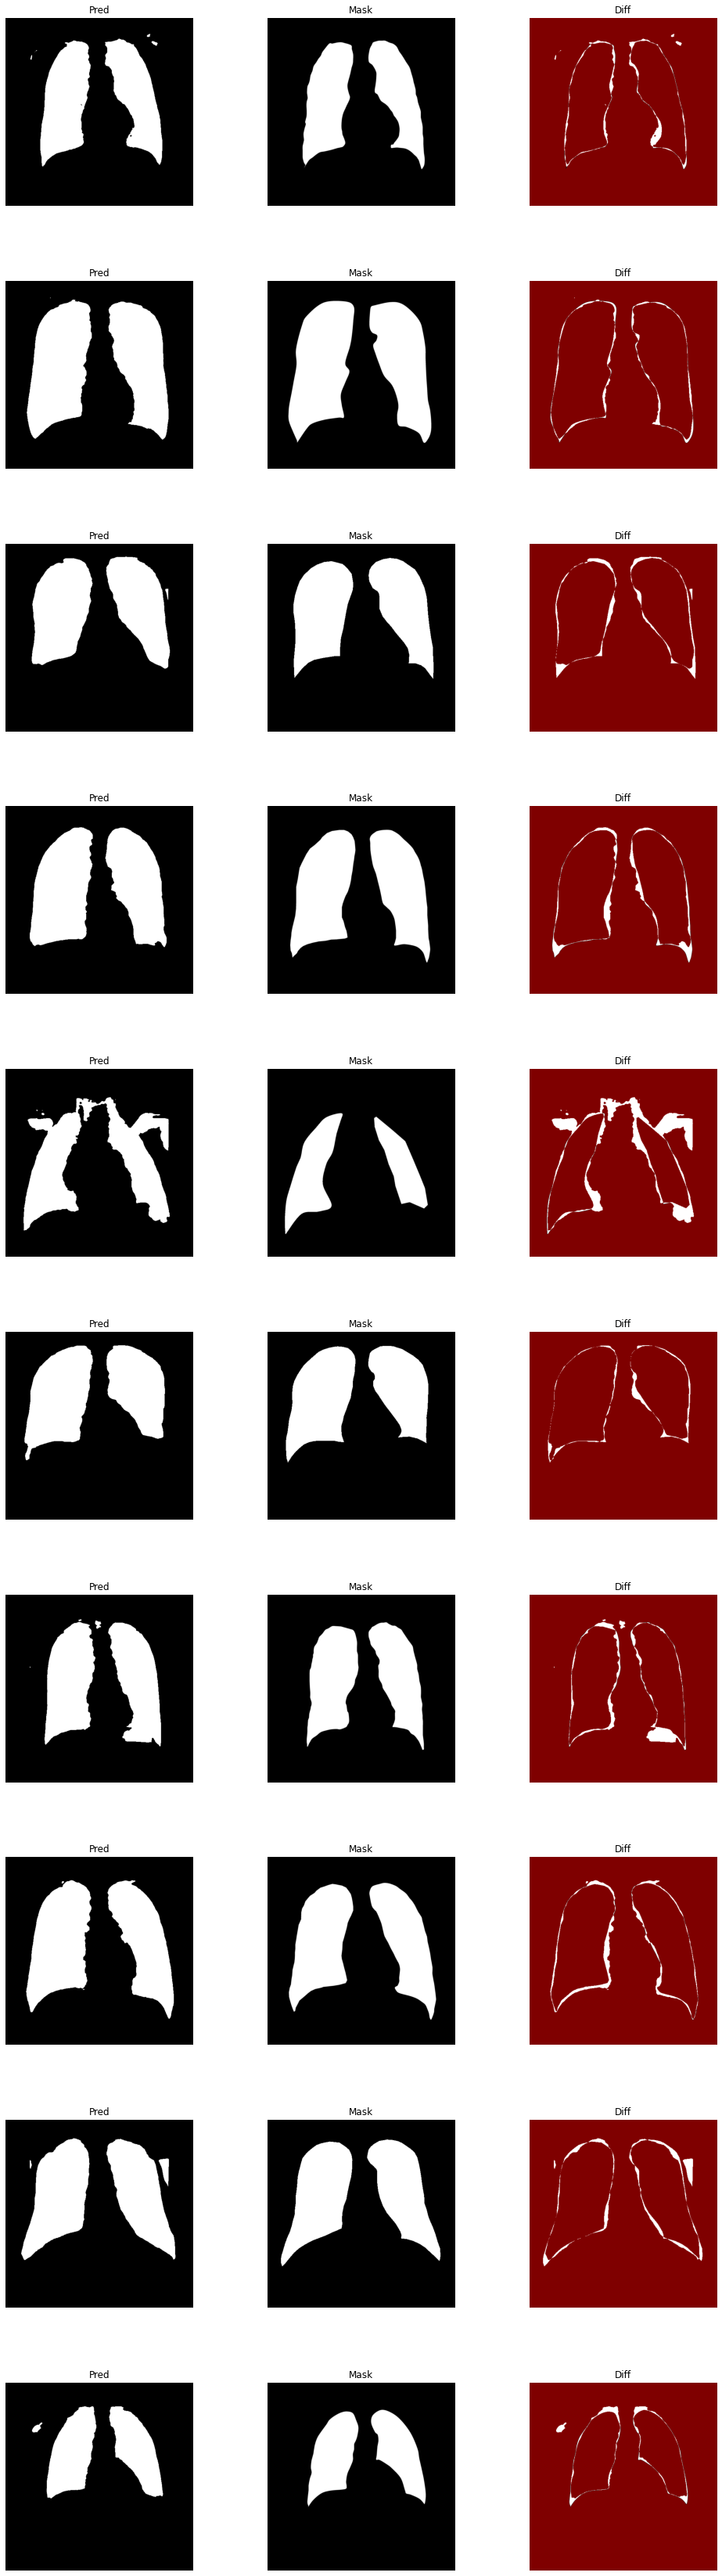

In [57]:
import os
import numpy as np
import matplotlib.pyplot as plt


outputs_dir = '/content/drive/MyDrive/Outputs'
fig, ax = plt.subplots(10, 3, figsize=(18, 60))
plt.subplots_adjust(wspace=0, hspace=0.4)

for i in range(10):
  img = image = plt.imread(os.path.join(outputs_dir, 'img' + str(i) + '.png'))
  mask = image = plt.imread(os.path.join(outputs_dir, 'mask' + str(i) + '.png'))
  img = np.stack((img,)*3, axis=-1)
  mask = np.stack((mask,)*3, axis=-1)
  similar_indices = np.where(np.equal(img, mask).all(axis=2))
  diff = mask + img
  diff[similar_indices] = [0.5, 0., 0.]
  ax[i, 0].imshow(img)
  ax[i, 0].axis('off')
  ax[i, 0].title.set_text('Pred')
  ax[i, 1].imshow(mask)
  ax[i, 1].axis('off')
  ax[i, 1].title.set_text('Mask')
  ax[i, 2].imshow(diff)
  ax[i, 2].axis('off')
  ax[i, 2].title.set_text('Diff')
plt.savefig('/content/Comp.png')